In [33]:
from dinocean.neverworld2.loader import *
from dinocean.neverworld2.plotter import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
run_dir = '/scratch2/tshahriar/DINO_1deg_outputs/runs/forward/spinup_200yr_visc2x/DINO_1deg_frd_200yr_from_rest_visc2x_run30983/'

d = DINOLoader(run_dir, prefix=['dynDiag'], niters=240, delta_t=1800)

In [77]:
target_lat = 26.0
d.compute_moc_diagnostics(target_lat=target_lat)

In [78]:
d.amoc_lat_sel

26.05283546447754

In [79]:
dp = DINOPlotter(d)

In [80]:
# fig, ax = dp.plot_sigma2_sections(timemean=True)
# ax.vline(-40, linestyle='--', color='grey')

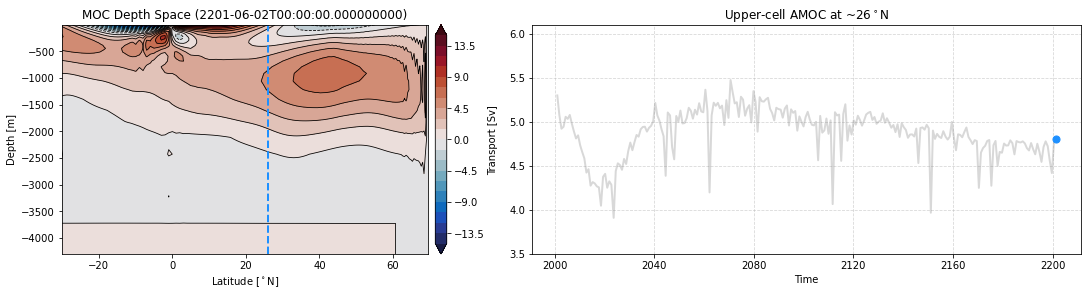

In [93]:
fig, axes = dp.plot_moc_with_amoc_timeseries(index_show=-1)
# axes[1].set_ylim([3.5, 6])
# fig.set_size_inches(20, 4)

(<Figure size 1080x432 with 3 Axes>,
 array([<AxesSubplot:title={'center':'MOC Depth Space (2201-06-02T00:00:00.000000000)'}, xlabel='Latitude [$^\\circ$N]', ylabel='Depth [m]'>,
        <AxesSubplot:title={'center':'Upper-cell AMOC at ~26$^\\circ$N'}, xlabel='Time'>],
       dtype=object))

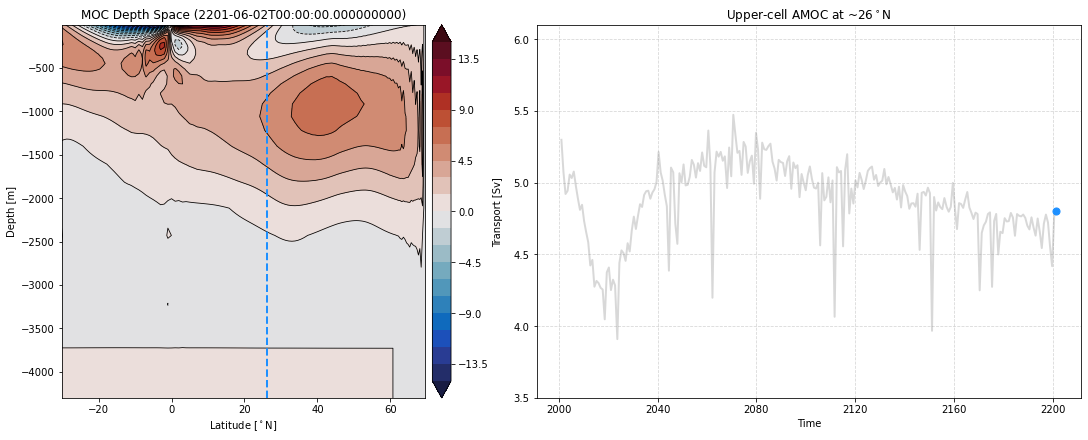

In [99]:
def modified_plot(*args, **kwargs):
    fig, axes = dp.plot_moc_with_amoc_timeseries(*args, **kwargs)
    axes[1].set_ylim([3.5, 6.1])
    fig.set_size_inches(15, 6)
    return fig, axes

modified_plot(index_show=-1)

In [ ]:
from dinocean.neverworld2.gif import *

gif_dir = f'/scratch/goldberg/dino_nw2/figs/for_tanvir//plot_moc_'
gm = GIFmaker(gif_dir, prefix="moc", dpi=150)
nt = d.ds.sizes['time']
gm.make_frames(
    nt=nt,
#    frame_func=lambda i: dp.plot_moc_with_amoc_timeseries(index_show=i),
    frame_func=lambda i: modified_plot(index_show=i),
    stride=1,
)

gm.show_slider()

gm.to_gif()

Frame 0/240
Frame 24/240
Frame 48/240
Frame 72/240
Frame 96/240
Frame 120/240
Frame 144/240


In [ ]:
gm.to_gif()

In [52]:
gm.show_slider()
